<a href="https://www.kaggle.com/code/sonawanelalitsunil/employee-1000x-ml-51?scriptVersionId=228809979" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/employee-data/Employee 1000x.csv


### Title: Employee 1000X

#### Description: A powerful workforce analytics tool that helps organizations optimize performance, track employee trends, and enhance productivity at scale. 🚀

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/employee-data/Employee 1000x.csv')

In [3]:
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,17-08-21,"Editor, commissioning"
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,28-06-69,Broadcast engineer
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,25-09-15,Industrial buyer
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,27-07-78,Multimedia specialist
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,17-11-89,Planning and development surveyor


In [4]:
df.tail()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
9995,9996,Tina,Sherman,Male,bartlettcolleen@example.org,(455)476-4044x5755,28-07-74,"Scientist, physiological"
9996,9997,Earl,Jennings,Female,andreabenton@example.com,009.056.6505,20-08-32,Warehouse manager
9997,9998,Ellen,Dominguez,Female,michaelayoder@example.net,409-428-4297x469,06-06-66,Lawyer
9998,9999,Emma,Clark,Male,pstrickland@example.com,849-868-8653,09-05-07,Accounting technician
9999,10000,Katrina,Schwartz,Female,andres56@example.org,001-874-330-5546x16770,14-08-35,Drilling engineer


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Index          10000 non-null  int64 
 1   First Name     10000 non-null  object
 2   Last Name      10000 non-null  object
 3   Sex            10000 non-null  object
 4   Email          10000 non-null  object
 5   Phone          10000 non-null  object
 6   Date of birth  10000 non-null  object
 7   Job Title      10000 non-null  object
dtypes: int64(1), object(7)
memory usage: 625.1+ KB


In [6]:
df.describe()

,Index
count,10000.00000
mean,5000.50000
std,2886.89568
min,1.00000
25%,2500.75000
50%,5000.50000
75%,7500.25000
max,10000.00000


In [7]:
df.isnull().sum()

Index            0
First Name       0
Last Name        0
Sex              0
Email            0
Phone            0
Date of birth    0
Job Title        0
dtype: int64

In [8]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [9]:
df.duplicated().sum()

0

In [10]:
df.shape

(10000, 8)

In [11]:
df.corr

<bound method DataFrame.corr of       Index First Name  Last Name     Sex                        Email  \
0         1       Sara    Mcguire  Female           tsharp@example.net   
1         2     Alisha     Hebert    Male   vincentgarrett@example.net   
2         3  Gwendolyn   Sheppard    Male  mercadojonathan@example.com   
3         4   Kristine     Mccann  Female        lindsay55@example.com   
4         5      Bobby    Pittman  Female    blevinsmorgan@example.com   
...     ...        ...        ...     ...                          ...   
9995   9996       Tina    Sherman    Male  bartlettcolleen@example.org   
9996   9997       Earl   Jennings  Female     andreabenton@example.com   
9997   9998      Ellen  Dominguez  Female    michaelayoder@example.net   
9998   9999       Emma      Clark    Male      pstrickland@example.com   
9999  10000    Katrina   Schwartz  Female         andres56@example.org   

                       Phone Date of birth                          Job Title  

In [12]:
df.dtypes

Index             int64
First Name       object
Last Name        object
Sex              object
Email            object
Phone            object
Date of birth    object
Job Title        object
dtype: object

In [13]:
df.columns

Index(['Index', 'First Name', 'Last Name', 'Sex', 'Email', 'Phone',
       'Date of birth', 'Job Title'],
      dtype='object')

## Data visualizations

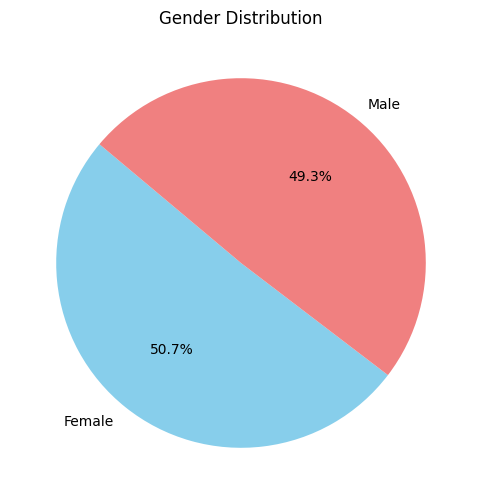

In [14]:
gender_counts = df['Sex'].value_counts()

# Plot a pie chart
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['skyblue', 'lightcoral'], startangle=140)
plt.title('Gender Distribution')
plt.show()

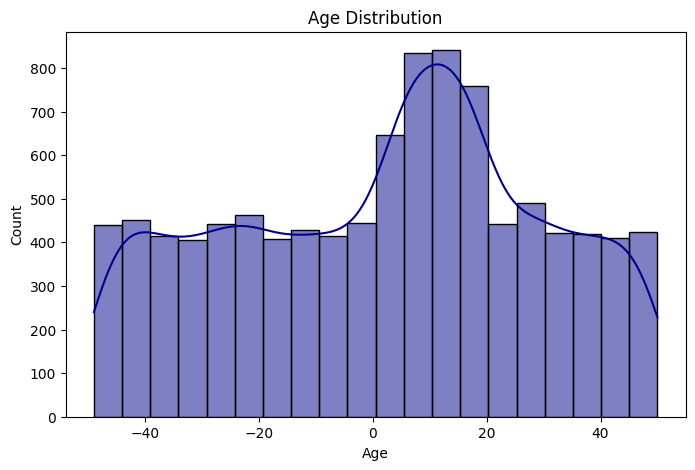

In [15]:
from datetime import datetime

# Convert 'Date of birth' to age
df['Date of birth'] = pd.to_datetime(df['Date of birth'], errors='coerce')
df['Age'] = df['Date of birth'].apply(lambda x: datetime.now().year - x.year if pd.notnull(x) else None)

# Plot the histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='darkblue')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()


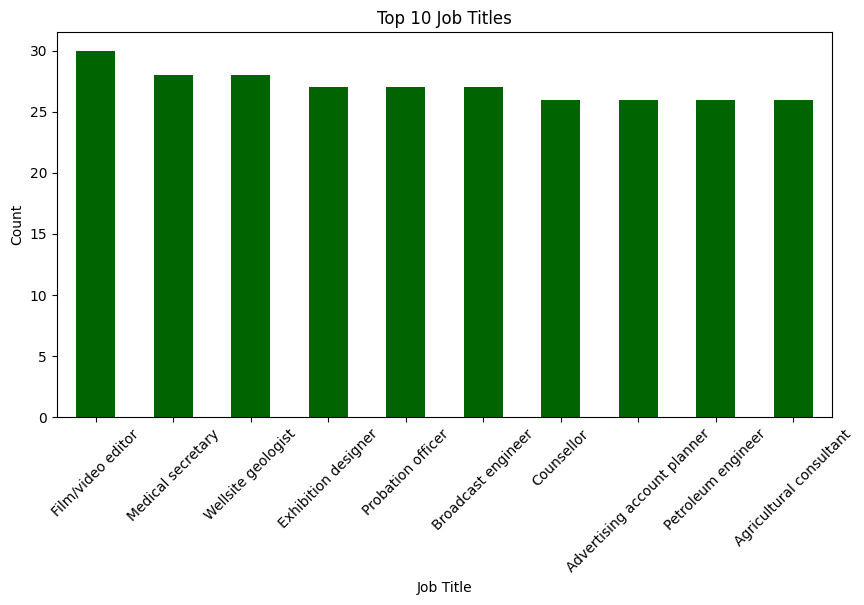

In [16]:
plt.figure(figsize=(10, 5))
df['Job Title'].value_counts().head(10).plot(kind='bar', color='darkgreen')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.title('Top 10 Job Titles')
plt.xticks(rotation=45)
plt.show()


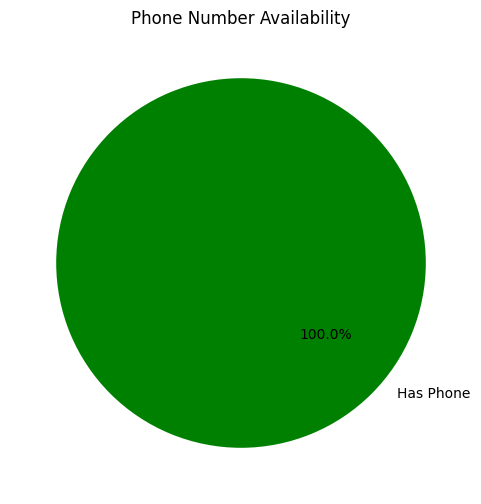

In [17]:
# Ensure 'Phone' column is treated properly
phone_counts = df['Phone'].notna().value_counts()

# Convert phone_counts to a list of values and dynamic labels
values = phone_counts.values
labels = ['Has Phone' if idx else 'No Phone' for idx in phone_counts.index]

# Plot the pie chart
plt.figure(figsize=(6, 6))
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=['green', 'red'], startangle=140)
plt.title('Phone Number Availability')
plt.show()

## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [19]:
# Create a subset of the data with features and target
features = df[['Age', 'Job Title']].copy()
target = df['Sex'].copy()

In [20]:
# Encode the target variable (assuming two classes: 'Male' and 'Female')
le = LabelEncoder()
target_encoded = le.fit_transform(target)

In [21]:
# One-hot encode the categorical predictor 'Job Title'
features_encoded = pd.get_dummies(features, columns=['Job Title'], drop_first=True)

In [22]:
# Standardize numerical features (recommended for models like SVM and KNN)
scaler = StandardScaler()
features_encoded[['Age']] = scaler.fit_transform(features_encoded[['Age']])

In [23]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_encoded, target_encoded, test_size=0.3, random_state=42, stratify=target_encoded)

In [24]:
# Define multiple ML algorithms
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "Support Vector Machine": SVC(kernel='rbf', probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}


In [25]:
# Train and evaluate models
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))

    # Print classification report
    print(f"\n{name} - Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))



Logistic Regression - Classification Report:

              precision    recall  f1-score   support

      Female       0.49      0.55      0.52      1522
        Male       0.47      0.41      0.44      1478

    accuracy                           0.48      3000
   macro avg       0.48      0.48      0.48      3000
weighted avg       0.48      0.48      0.48      3000


Random Forest - Classification Report:

              precision    recall  f1-score   support

      Female       0.50      0.53      0.51      1522
        Male       0.48      0.45      0.47      1478

    accuracy                           0.49      3000
   macro avg       0.49      0.49      0.49      3000
weighted avg       0.49      0.49      0.49      3000


Gradient Boosting - Classification Report:

              precision    recall  f1-score   support

      Female       0.51      0.92      0.66      1522
        Male       0.52      0.08      0.14      1478

    accuracy                           0.51      

In [26]:
# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

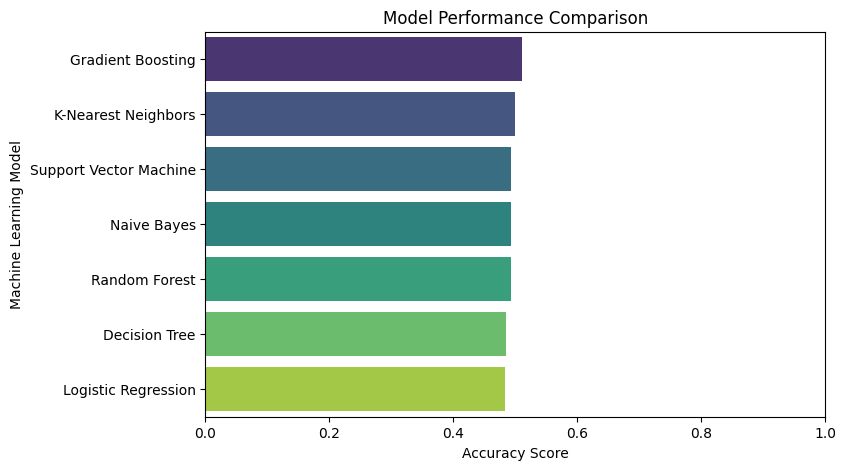

In [27]:
# Plot model comparison
plt.figure(figsize=(8, 5))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")
plt.title("Model Performance Comparison")
plt.xlabel("Accuracy Score")
plt.ylabel("Machine Learning Model")
plt.xlim(0, 1)
plt.show()

## Thank you...!!! pls upvote!!!